# CFPB Complaints — Logistic Regression on TF-IDF

Interpretable baseline for 10-class product classification, benchmarked against a
fine-tuned DistilBERT on identical data.

This notebook owns the **split**, and the split is where this project's real work is.
It writes `train/val/test.parquet` — time-ordered, train on the past and evaluate on months
the model has never seen — so DistilBERT is scored on the exact same rows.

Four properties the split must have, none of which the first version had:

1. **No text can straddle two splits** — not even after cleaning. Step 2 drops 24,029 rows
   it cannot use, then collapses the remaining 383,292 to 334,658 distinct
   complaints, because the corpus is full of template letters filed hundreds or thousands
   of times.
2. **No time period can straddle them either.** The class mix is not stationary, so a random
   split trains and tests on the same filing surge.
3. **Evaluation is never rebalanced.** Training may be; test must look like reality.
4. **A held-out validation set** does model selection, so the test set is read once.

In [64]:
import hashlib
import os
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PARQUET = "cfpb_filtered.parquet"

pd.set_option("display.max_colwidth", 60)
print("pandas", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.0
scikit-learn 1.9.0


## Step 1 — Load the filtered data

Reads the parquet and keeps `narrative` (text), `product` (label) and `date_received`
(needed for the temporal split in Step 3).

In [65]:
df = pd.read_parquet(PARQUET, columns=["narrative", "product", "date_received"])

print("shape:", df.shape)
print()
class_counts = df["product"].value_counts()
print(class_counts.to_string())

EXPECTED_ROWS, EXPECTED_CLASSES = 407_321, 10
assert len(df) == EXPECTED_ROWS, f"expected {EXPECTED_ROWS:,} rows, got {len(df):,}"
assert df["product"].nunique() == EXPECTED_CLASSES, (
    f"expected {EXPECTED_CLASSES} classes, got {df['product'].nunique()}"
)
print(f"\nCheckpoint OK: {len(df):,} rows, {df['product'].nunique()} classes")
print(f"raw imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x")

shape: (407321, 3)

product
Debt collection                                            134953
Money transfer, virtual currency, or money service          72921
Checking or savings account                                 69343
Credit card                                                 58916
Mortgage                                                    20497
Vehicle loan or lease                                       16712
Student loan                                                14163
Payday loan, title loan, personal loan, or advance loan     11271
Prepaid card                                                 5014
Debt or credit management                                    3531

Checkpoint OK: 407,321 rows, 10 classes
raw imbalance ratio (max/min): 38.2x


## Step 2 — Deduplicate on a canonical key

The CFPB pool is template-driven — the single most-filed text in it was filed 7,111 times,
as Step 2's output below reports. Splitting rows at random puts copies of the same letter
on both sides of the split, so the model is scored on text it memorised.

Deduplicating on the raw `narrative` is **not enough**. The model never sees the raw string
— it sees `clean_text(narrative)`, which strips digits, punctuation and case. Two narratives
that differ only in a redacted amount collapse to the same input after cleaning. That collapse
hits Logistic Regression harder than DistilBERT, because LR's cleaning is the more
aggressive of the two — compare `clean_text` in Step 4 with the DistilBERT notebook's
`light_clean` — so leaving it unhandled hands LR a memorisation advantage in the very
comparison this project exists to make.

So the key used for deduplication, conflict detection and splitting is `canon()` — the same
normalisation the model input goes through. Two documents the model cannot tell apart are
treated as one document here.

Two by-products, both used later:

- **Conflicting labels.** Where one key carries more than one `product`, the label is not
  recoverable and the rows are dropped. The count below is concentrated — a couple of
  hundred keys covering tens of thousands of rows, so over a hundred filings each — which
  makes them mass-filed templates where a few filers chose another drop-down, not a
  label-noise rate.
- **`n_copies`.** How many times each key was filed, recorded *before* deduplication, so
  Step 6 can report both a text-diversity view and an intake-volume view of the same test
  set without ever putting a duplicate into training.

In [66]:
# Split key: the same normalisation clean_text applies, run BEFORE the split so that two
# narratives the model cannot tell apart can never land on opposite sides of it.
DATE_MASK = re.compile(r"X{2}/X{2}/(?:X+|\d{2,4}|year>|scrub>)?")
X_RUN = re.compile(r"X{2,}")
NON_ALPHA = re.compile(r"[^a-z\s]")
WS = re.compile(r"\s+")


def canon(text: str) -> str:
    text = DATE_MASK.sub(" ", text)
    text = X_RUN.sub(" ", text)
    text = text.lower()
    text = NON_ALPHA.sub(" ", text)
    return WS.sub(" ", text).strip()


df["canon_key"] = df["narrative"].map(canon)
# Stored on disk in place of the full normalised text -- it is only ever used for
# set-membership and joins, and keeping the text doubled every parquet file.
def key_hash(k):
    return hashlib.sha1(k.encode()).hexdigest()[:16]

n_before = len(df)
df = df[df["canon_key"].str.len() > 0]
print(f"dropped {n_before - len(df)} rows that normalise to an empty string")

# Same wording, different product -> the label is not recoverable. Drop the key entirely.
n_labels = df.groupby("canon_key")["product"].nunique()
conflicting = set(n_labels[n_labels > 1].index)
conflict_rows = int(df["canon_key"].isin(conflicting).sum())
print(f"conflicting keys : {len(conflicting):,}  ({conflict_rows:,} rows, "
      f"{100 * conflict_rows / len(df):.1f}% of the rows)")
df = df[~df["canon_key"].isin(conflicting)]

# Multiplicity recorded BEFORE dedup, so the intake-volume view stays available.
df["n_copies"] = df["canon_key"].map(df["canon_key"].value_counts())

df["key"] = df["canon_key"].map(key_hash)
pool = df.drop_duplicates(subset="canon_key").reset_index(drop=True)
assert pool["key"].nunique() == len(pool), "hash collision in the split key"

pool_counts = pool["product"].value_counts()
print(f"\nPOOL after canonical dedup: {len(pool):,} distinct complaints "
      f"(from the {len(df):,} rows kept of {n_before:,})")
print(f"imbalance ratio           : {pool_counts.max() / pool_counts.min():.1f}x")
print(f"most-filed single text    : {pool['n_copies'].max():,} copies")
print()
print((pool_counts / len(pool) * 100).round(2).to_string())

dropped 22 rows that normalise to an empty string
conflicting keys : 210  (24,007 rows, 5.9% of the rows)

POOL after canonical dedup: 334,658 distinct complaints (from the 383,292 rows kept of 407,321)
imbalance ratio           : 28.9x
most-filed single text    : 7,111 copies

product
Debt collection                                            29.44
Checking or savings account                                19.31
Credit card                                                16.78
Money transfer, virtual currency, or money service         13.37
Mortgage                                                    6.12
Vehicle loan or lease                                       4.95
Student loan                                                4.16
Payday loan, title loan, personal loan, or advance loan     3.35
Prepaid card                                                1.50
Debt or credit management                                   1.02


## Step 3 — A time-ordered split, and the training set is the only one that gets rebalanced

**Training data may be rebalanced. Evaluation data may not.** The first version of this
notebook capped every class at 8,000 rows *before* splitting, which left the test set close
to uniform while the real pool runs about 29:1. Every per-class number it produced was
measured against a world that does not exist.

Here the cap is applied to the training pool **only**, after the evaluation sets are already
held out at their own distribution. The cap is a **GPU budget** — `class_weight='balanced'`
in Step 5 is what handles imbalance, and it does so regardless of the cap.

    train  <= 2025-12        val  2026-01/02        test  2026-03/04

Two costs the split still carries, both stated rather than hidden:

1. **The test score confounds two things** — generalising to unseen text, and absorbing the
   shift in class mix. A single test number cannot say which of the two moved.
2. **Deduplication runs before the date cut** (Step 2) and keeps one arbitrary copy per
   canonical key, so a template filed in both 2025 and 2026 may survive only in the training
   window. The test set is therefore skewed toward genuinely novel text — harder than real
   intake, where repeat templates do arrive.

In [67]:
CAP = 8_000


def cap_training_pool(frame, cap=CAP, seed=RANDOM_STATE):
    """Compute budget only -- never applied to val or test."""
    parts = [g.sample(n=min(len(g), cap), random_state=seed)
             for _, g in frame.groupby("product", sort=False)]
    return pd.concat(parts, ignore_index=True)


def no_leakage(*frames):
    keys = [set(f["canon_key"]) for f in frames]
    for a in range(len(keys)):
        for b in range(a + 1, len(keys)):
            assert not (keys[a] & keys[b]), f"canonical-key leak between split {a} and {b}"
    return True


COLS = ["narrative", "product", "key", "n_copies"]

# Time-ordered: train on the past, evaluate on months the model has never seen. The cut
# points are calendar month boundaries, so no month is split across two sets.
#
# TEST_END is a deliberate upper bound, not an oversight. Everything from 2026-05 on is still
# filling in -- the CFPB publishes a narrative only after the company responds or 60 days
# pass, and fast responders (banks) publish before slow ones (debt collectors). Those months
# are therefore biased, not merely small, so they are excluded from every split rather than
# scored.
TRAIN_END, VAL_END, TEST_END = "2026-01-01", "2026-03-01", "2026-05-01"

d = pd.to_datetime(pool["date_received"])
train_pool = pool[d < TRAIN_END]
val_df = pool[(d >= TRAIN_END) & (d < VAL_END)].reset_index(drop=True)
test_df = pool[(d >= VAL_END) & (d < TEST_END)].reset_index(drop=True)
train_df = cap_training_pool(train_pool)
no_leakage(train_df, val_df, test_df)

for name, dd in [("train", train_df), ("val", val_df), ("test", test_df)]:
    dd[COLS].to_parquet(f"{name}.parquet", index=False)

tc = train_df["product"].value_counts()
vc = test_df["product"].value_counts()
print(f"train pool {len(train_pool):,} (< {TRAIN_END}) -> capped {len(train_df):,}"
      f"  ({(tc == CAP).sum()} classes at the cap, {(tc < CAP).sum()} taken in full)")
print(f"val {len(val_df):,} ({TRAIN_END}..{VAL_END}) | "
      f"test {len(test_df):,} ({VAL_END}..{TEST_END})   (neither is capped)")
print(f"excluded as still-filling-in: {int((d >= TEST_END).sum()):,} rows from {TEST_END} on")
print(f"train imbalance {tc.max() / tc.min():.2f}x  vs  test imbalance {vc.max() / vc.min():.1f}x")
print(f"rarest class in test: {vc.iloc[-1]:,} rows ({vc.index[-1]})"
      "  <- per-class F1 is noisy here")
print("canonical-key leakage: none")

print("\nclass share (%) -- the test months still do not match the pooled window. Note that")
print("this table cannot separate drift from intake lag, and pool includes the test months")
print(pd.DataFrame({
    "pool (all months)": pool["product"].value_counts(normalize=True) * 100,
    "test (2026-03/04)": test_df["product"].value_counts(normalize=True) * 100,
}).round(2).to_string())

X_train, y_train = train_df["narrative"], train_df["product"]
X_val, y_val = val_df["narrative"], val_df["product"]
X_test, y_test = test_df["narrative"], test_df["product"]

train pool 246,318 (< 2026-01-01) -> capped 70,114  (7 classes at the cap, 3 taken in full)
val 29,705 (2026-01-01..2026-03-01) | test 36,615 (2026-03-01..2026-05-01)   (neither is capped)
excluded as still-filling-in: 22,020 rows from 2026-05-01 on
train imbalance 3.15x  vs  test imbalance 28.1x
rarest class in test: 381 rows (Debt or credit management)  <- per-class F1 is noisy here
canonical-key leakage: none

class share (%) -- the test months still do not match the pooled window. Note that
this table cannot separate drift from intake lag, and pool includes the test months
                                                         pool (all months)  test (2026-03/04)
product                                                                                      
Debt collection                                                      29.44              29.24
Checking or savings account                                          19.31              19.67
Credit card                             

## Step 4 — Cleaning + TF-IDF

`clean_text` is the model's actual input pipeline. It is the same normalisation as `canon()`
in Step 2 — deliberately, because the split key has to be at least as aggressive as the
feature pipeline or documents the model sees as identical can still straddle the split.

The redaction patterns were read off the file, not assumed: the CFPB masks personal data as
`XXXX` runs and `XX/XX/XXXX` dates. Masks are stripped **before** lowercasing (the `X`s are
uppercase), longest patterns first, then leftover `X` runs, then case and non-alphabetic
characters.

TF-IDF is **fit on train only**. Val and test are transformed with train's vocabulary.

In [68]:
def clean_text(text: str) -> str:
    """Model input pipeline. Identical to canon() in Step 2 -- see the note above."""
    text = DATE_MASK.sub(" ", text)   # XX/XX/XXXX, XX/XX/year>, XX/XX/2025, XX/XX/
    text = X_RUN.sub(" ", text)       # leftover XXXX / XXXXXXXX runs
    text = text.lower()
    text = NON_ALPHA.sub(" ", text)   # punctuation, digits, stray symbols
    return WS.sub(" ", text).strip()


sample = train_df.loc[train_df["narrative"].str.contains("XX/XX/", regex=False), "narrative"].iloc[0]
print("BEFORE:", sample[:200].replace("\n", " "))
print()
print("AFTER :", clean_text(sample)[:200])

# The split key was built with exactly this function, so this must hold.
assert (train_df["narrative"].head(500).map(clean_text)
        == train_df["canon_key"].head(500)).all(), "canon() and clean_text() have diverged"
print("\nsplit key and model input agree")

BEFORE: On XX/XX/XXXX, I discovered that I had 11 federal loans under my name after applying for a mortgage and having a credit check done. At that point, I found out that the loans were delinquent for 132 da

AFTER : on i discovered that i had federal loans under my name after applying for a mortgage and having a credit check done at that point i found out that the loans were delinquent for days because i was unaw

split key and model input agree


In [69]:
X_train_clean = X_train.map(clean_text)
X_val_clean = X_val.map(clean_text)
X_test_clean = X_test.map(clean_text)

vectorizer = TfidfVectorizer(
    max_features=20_000,
    stop_words="english",
    ngram_range=(1, 2),
)

X_train_tfidf = vectorizer.fit_transform(X_train_clean)  # FIT on train only
X_val_tfidf = vectorizer.transform(X_val_clean)
X_test_tfidf = vectorizer.transform(X_test_clean)

print("TF-IDF train matrix:", X_train_tfidf.shape)
print("TF-IDF val   matrix:", X_val_tfidf.shape)
print("TF-IDF test  matrix:", X_test_tfidf.shape)
print(f"vocabulary size    : {len(vectorizer.vocabulary_):,}")
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"sparse density     : {density:.4%}  ({X_train_tfidf.nnz:,} stored values)")

TF-IDF train matrix: (70114, 20000)
TF-IDF val   matrix: (29705, 20000)
TF-IDF test  matrix: (36615, 20000)
vocabulary size    : 20,000
sparse density     : 0.4365%  (6,121,614 stored values)


## Step 5 — Train Logistic Regression

`class_weight='balanced'` is the imbalance handling, and it is doing the work on its own:
it reweights each class to equal total weight, which is what the per-class cap in Step 3 was
previously credited with. The cap is a compute budget; it is not part of the imbalance
strategy. Step 7 measures what the cap costs.

One consequence worth naming now, because it shows up in Step 6: `class_weight='balanced'`
means the model is effectively fit to a **uniform** class prior, while the test set runs at
about 28:1. The model will over-predict rare classes on it. That is a real deployment effect,
not a bug, and Step 6 shows it as per-class precision running well below per-class recall
**on the rare classes** — Prepaid card scores 0.23 precision against 0.73 recall. On the four
largest classes the same reweighting runs the other way, buying precision at recall's expense.

No hyperparameter search is run — sklearn defaults (`C=1.0`, L2, lbfgs). DistilBERT likewise
uses one fixed configuration. Neither model is tuned, so neither gets an advantage there.

In [70]:
def fit_lr(max_iter: int):
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        t0 = time.time()
        clf.fit(X_train_tfidf, y_train)
        elapsed = time.time() - t0
    converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
    return clf, converged, elapsed


clf, converged, t_fit = fit_lr(1000)
print(f"fit with max_iter=1000 in {t_fit:.1f}s  (converged: {converged})")

if not converged:
    print("ConvergenceWarning raised -> refitting at max_iter=2000")
    clf, converged, t_fit = fit_lr(2000)
    print(f"fit with max_iter=2000 in {t_fit:.1f}s  (converged: {converged})")
    if not converged:
        print("STILL not converged -- metrics below are usable but consider max_iter=4000")

print(f"\nclasses: {len(clf.classes_)}")
print(f"coefficient matrix: {clf.coef_.shape}")
print(f"TRAINING TIME: {t_fit:.1f}s on CPU")

fit with max_iter=1000 in 9.3s  (converged: True)

classes: 10
coefficient matrix: (10, 20000)
TRAINING TIME: 9.3s on CPU


## Step 6 — Evaluate

The headline is **macro F1**: all ten routing queues matter equally, regardless of how much
traffic each one carries. That is a statement about the decision, not about the metric.

Four things this step reports that the first version did not:

1. **Floor baselines.** On a 28:1 test set, "always predict Debt collection" scores 0.292
   accuracy — which sounds respectable and is worthless. Its macro F1 is 0.045. Quoting an
   accuracy floor next to a macro-F1 headline invites exactly the wrong comparison.
2. **Per-class support.** Support now ranges from 381 to ~10,700. A per-class F1 column
   without a support column beside it cannot be read.
3. **Two distribution views of the same test set.** Unweighted counts each distinct complaint
   once; `sample_weight=n_copies` counts it as often as it was actually filed. The first
   asks "can the model read complaints?", the second "can it handle the intake queue?".
4. **Balanced accuracy**, which is macro recall and is invariant to the prior shift above.

In [71]:
y_pred = clf.predict(X_test_tfidf)

labels = sorted(y_test.unique())
print(classification_report(y_test, y_pred, labels=labels, digits=3, zero_division=0))

                                                         precision    recall  f1-score   support

                            Checking or savings account      0.813     0.740     0.775      7201
                                            Credit card      0.852     0.780     0.815      6861
                                        Debt collection      0.931     0.819     0.871     10706
                              Debt or credit management      0.150     0.556     0.236       381
     Money transfer, virtual currency, or money service      0.735     0.663     0.697      3455
                                               Mortgage      0.931     0.927     0.929      2641
Payday loan, title loan, personal loan, or advance loan      0.515     0.768     0.617      1430
                                           Prepaid card      0.226     0.731     0.345       431
                                           Student loan      0.913     0.923     0.918      1459
                             

In [72]:
w = test_df["n_copies"].values   # intake-volume view: how often each text was really filed

macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

macro_f1_w = f1_score(y_test, y_pred, average="macro", zero_division=0, sample_weight=w)
accuracy_w = accuracy_score(y_test, y_pred, sample_weight=w)
weighted_f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0, sample_weight=w)
bal_acc_w = balanced_accuracy_score(y_test, y_pred, sample_weight=w)

print(f"{'':<26}{'text diversity':>16}{'intake volume':>16}")
print(f"{'macro F1':<26}{macro_f1:>16.4f}{macro_f1_w:>16.4f}")
print(f"{'accuracy':<26}{accuracy:>16.4f}{accuracy_w:>16.4f}")
print(f"{'weighted F1':<26}{weighted_f1:>16.4f}{weighted_f1_w:>16.4f}")
print(f"{'balanced accuracy':<26}{bal_acc:>16.4f}{bal_acc_w:>16.4f}")
print()

# --- floor baselines ------------------------------------------------------------
maj_pred = np.full(len(y_test), pool["product"].value_counts().idxmax())
rng = np.random.default_rng(RANDOM_STATE)
prior = pool["product"].value_counts(normalize=True)
rand_pred = rng.choice(prior.index.to_numpy(), size=len(y_test), p=prior.to_numpy())

print(f"{'baseline':<34}{'accuracy':>10}{'macro F1':>10}")
for name, pred in [("always predict the largest class", maj_pred),
                   ("random draw from the class prior", rand_pred)]:
    print(f"{name:<34}{accuracy_score(y_test, pred):>10.3f}"
          f"{f1_score(y_test, pred, average='macro', zero_division=0):>10.3f}")
print(f"{'Logistic Regression':<34}{accuracy:>10.3f}{macro_f1:>10.3f}")
print()
print("NOTE: 'always predict the largest class' looks respectable on accuracy and is")
print("      worthless on macro F1. The macro-F1 floor is the one to compare against.")

                            text diversity   intake volume
macro F1                            0.7030          0.7084
accuracy                            0.7898          0.8070
weighted F1                         0.8061          0.8227
balanced accuracy                   0.7766          0.7838

baseline                            accuracy  macro F1
always predict the largest class       0.292     0.045
random draw from the class prior       0.179     0.100
Logistic Regression                    0.790     0.703

NOTE: 'always predict the largest class' looks respectable on accuracy and is
      worthless on macro F1. The macro-F1 floor is the one to compare against.


saved confusion_matrix_lr.png  (row-normalised)


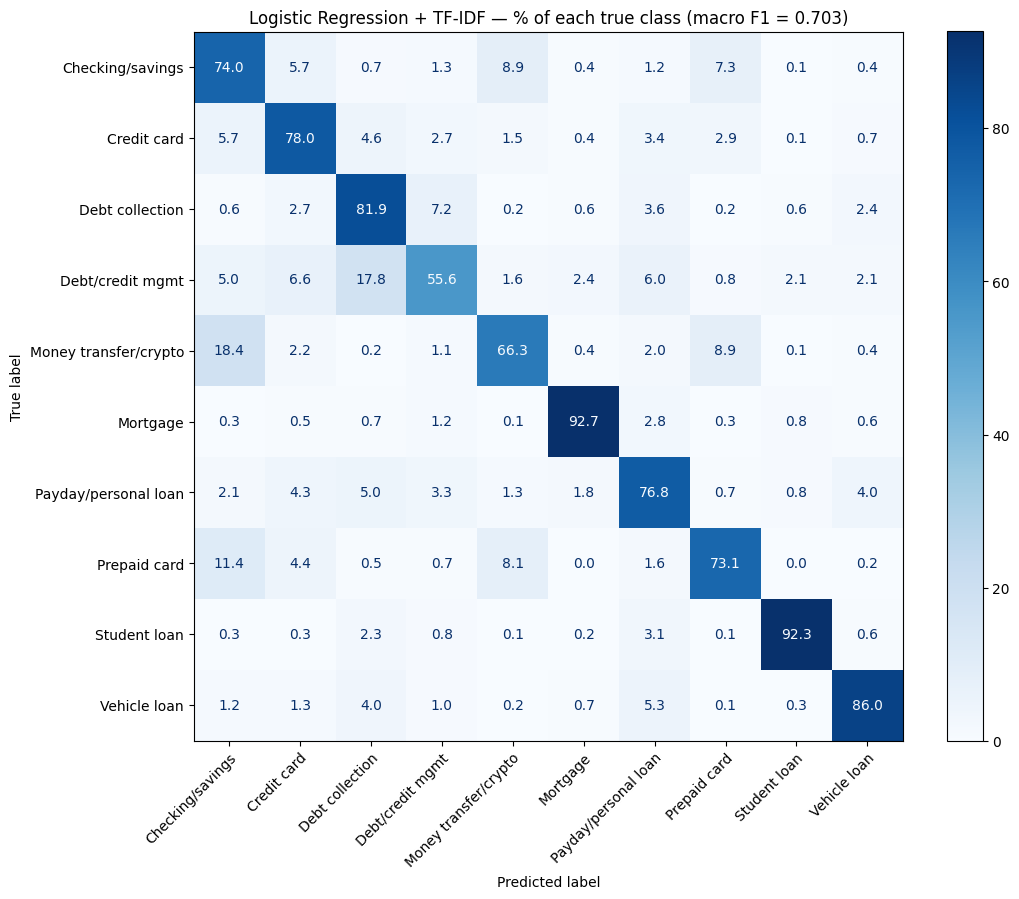

In [73]:
SHORT = {
    "Debt collection": "Debt collection",
    "Money transfer, virtual currency, or money service": "Money transfer/crypto",
    "Checking or savings account": "Checking/savings",
    "Credit card": "Credit card",
    "Mortgage": "Mortgage",
    "Vehicle loan or lease": "Vehicle loan",
    "Student loan": "Student loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/personal loan",
    "Prepaid card": "Prepaid card",
    "Debt or credit management": "Debt/credit mgmt",
}
short_labels = [SHORT.get(c, c) for c in labels]

cm = confusion_matrix(y_test, y_pred, labels=labels)

# Row-normalised: class supports now span 381 to ~10,700, so a raw-count matrix renders the
# rare-class rows invisible. Each row is the share of that true class sent to each label.
cm_pct = 100 * cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm_pct, display_labels=short_labels).plot(
    ax=ax, cmap="Blues", values_format=".1f", colorbar=True, xticks_rotation=45
)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
ax.set_title(f"Logistic Regression + TF-IDF — % of each true class (macro F1 = {macro_f1:.3f})")
fig.tight_layout()
fig.savefig("confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
print("saved confusion_matrix_lr.png  (row-normalised)")
plt.show()

### Interpretation — strongest/weakest classes and the top confusions

Computed rather than eyeballed, so the numbers quoted in the report's Business Insights
section come straight from the matrix.

In [74]:
per_class = pd.DataFrame({
    "f1": f1_score(y_test, y_pred, labels=labels, average=None, zero_division=0),
    "support": [int((y_test == c).sum()) for c in labels],
}, index=labels).sort_values("f1", ascending=False)
per_class["short"] = [SHORT[c] for c in per_class.index]

print("per-class F1 with support (support matters: it spans 381 to ~10,700):")
print(per_class[["short", "f1", "support"]].round(3).to_string(index=False))
print()
print(f"BEST : {per_class.index[0]!r}  F1={per_class.iloc[0]['f1']:.3f}  n={per_class.iloc[0]['support']:,}")
print(f"WORST: {per_class.index[-1]!r}  F1={per_class.iloc[-1]['f1']:.3f}  n={per_class.iloc[-1]['support']:,}")

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
pairs = [
    {"true": SHORT[t], "predicted": SHORT[p], "n": int(cm_df.loc[t, p]),
     "pct_of_true_class": 100 * cm_df.loc[t, p] / cm_df.loc[t].sum()}
    for t in labels for p in labels if t != p
]
top_conf = (pd.DataFrame(pairs).sort_values("pct_of_true_class", ascending=False)
            .head(10).reset_index(drop=True))
top_conf["pct_of_true_class"] = top_conf["pct_of_true_class"].round(1)
print("\ntop 10 confusions (share of the true class sent to the wrong label):")
print(top_conf.to_string(index=False))

per-class F1 with support (support matters: it spans 381 to ~10,700):
                short    f1  support
             Mortgage 0.929     2641
         Student loan 0.918     1459
      Debt collection 0.871    10706
         Vehicle loan 0.829     2050
          Credit card 0.815     6861
     Checking/savings 0.775     7201
Money transfer/crypto 0.697     3455
 Payday/personal loan 0.617     1430
         Prepaid card 0.345      431
     Debt/credit mgmt 0.236      381

BEST : 'Mortgage'  F1=0.929  n=2,641
WORST: 'Debt or credit management'  F1=0.236  n=381

top 10 confusions (share of the true class sent to the wrong label):
                 true             predicted   n  pct_of_true_class
Money transfer/crypto      Checking/savings 637               18.4
     Debt/credit mgmt       Debt collection  68               17.8
         Prepaid card      Checking/savings  49               11.4
     Checking/savings Money transfer/crypto 638                8.9
Money transfer/crypto       

### Why those pairs — lexical overlap between classes

The confusion matrix says *which* categories get mixed up; it does not say why. Represent
each class as the mean TF-IDF vector of its training complaints and the cosine between two
of those centroids is a measure of how much vocabulary the pair shares. Plotted against how
often the pair is actually swapped, it turns "these categories sound alike" into a testable
claim.

Similarity is measured on the **training** set (the vectoriser never saw test), the error
rate on the **held-out test** set, so the two axes come from disjoint data.


Spearman rho = 0.685   p = 2.12e-07   (n = 45 pairs)

most-confused pairs:
                                    pair  similarity  swapped  swapped_pct
Checking/savings / Money transfer/crypto       0.451     1275       11.965
    Money transfer/crypto / Prepaid card       0.376      341        8.775
         Checking/savings / Prepaid card       0.610      577        7.560
      Debt collection / Debt/credit mgmt       0.772      838        7.558
          Checking/savings / Credit card       0.697      799        5.682

most lexically similar pairs:
                                   pair  similarity  swapped  swapped_pct
     Debt collection / Debt/credit mgmt       0.772      838        7.558
    Payday/personal loan / Vehicle loan       0.746      165        4.741
Debt/credit mgmt / Payday/personal loan       0.732       70        3.865
         Credit card / Debt/credit mgmt       0.723      213        2.941
         Checking/savings / Credit card       0.697      799        5.682


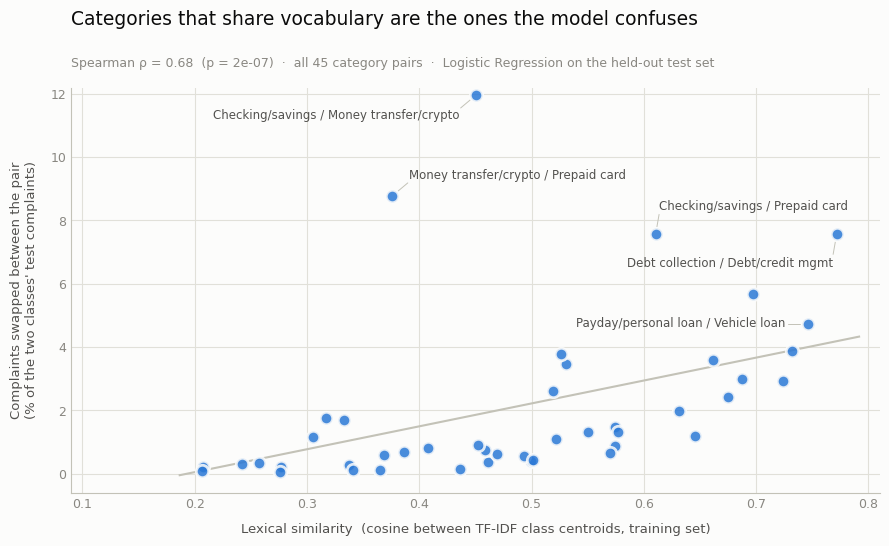

In [75]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from matplotlib.transforms import Bbox

# Each class as the mean TF-IDF vector of its training complaints.
centroids = np.vstack(
    [np.asarray(X_train_tfidf[(y_train == c).values].mean(axis=0)).ravel() for c in labels]
)
similarity = cosine_similarity(centroids)

# Pair up every class pair: shared vocabulary vs how often they are swapped.
row_totals = cm.sum(axis=1)
pairs_df = pd.DataFrame([
    {
        "pair": f"{SHORT[labels[i]]} / {SHORT[labels[j]]}",
        "similarity": similarity[i, j],
        "swapped": int(cm[i, j] + cm[j, i]),
        # normalised so the big classes do not dominate purely by being big
        "swapped_pct": 100 * (cm[i, j] + cm[j, i]) / (row_totals[i] + row_totals[j]),
    }
    for i in range(len(labels)) for j in range(i + 1, len(labels))
])

rho, p_value = spearmanr(pairs_df["similarity"], pairs_df["swapped_pct"])
print(f"Spearman rho = {rho:.3f}   p = {p_value:.2e}   (n = {len(pairs_df)} pairs)")
print()
print("most-confused pairs:")
print(pairs_df.nlargest(5, "swapped_pct").round(3).to_string(index=False))
print()
print("most lexically similar pairs:")
print(pairs_df.nlargest(5, "similarity").round(3).to_string(index=False))

# --- chart ---------------------------------------------------------------
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES = "#e1e0d9", "#c3c2b7", "#2a78d6"

fig, ax = plt.subplots(figsize=(9, 5.6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# Straight-line guide, drawn under the marks; the quoted statistic is the rank
# correlation, so the line is a reading aid rather than the model being claimed.
slope, intercept = np.polyfit(pairs_df["similarity"], pairs_df["swapped_pct"], 1)
xs = np.linspace(pairs_df["similarity"].min() - 0.02, pairs_df["similarity"].max() + 0.02, 50)
ax.plot(xs, intercept + slope * xs, color=AXIS, lw=1.5, zorder=1)

ax.scatter(pairs_df["similarity"], pairs_df["swapped_pct"], s=80, c=SERIES,
           alpha=0.85, edgecolors=SURFACE, linewidths=2, zorder=3)

ax.set_axisbelow(True)
ax.grid(True, color=GRID, lw=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
    ax.spines[side].set_linewidth(0.8)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
ax.set_xlabel("Lexical similarity  (cosine between TF-IDF class centroids, training set)",
              fontsize=9.5, color=INK2, labelpad=9)
ax.set_ylabel("Complaints swapped between the pair\n(% of the two classes' test complaints)",
              fontsize=9.5, color=INK2, labelpad=9)
ax.set_xlim(0.09, 0.81)
ax.set_ylim(-0.6, 12.2)
ax.text(0, 1.145, "Categories that share vocabulary are the ones the model confuses",
        transform=ax.transAxes, fontsize=13.5, color=INK, va="bottom")
ax.text(0, 1.045,
        f"Spearman \u03c1 = {rho:.2f}  (p = {p_value:.0e})  \u00b7  all {len(pairs_df)} "
        "category pairs  \u00b7  Logistic Regression on the held-out test set",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")


# Label the extremes and the off-trend pairs only -- a label on all 45 is unreadable.
ANNOTATE = [
    "Checking/savings / Money transfer/crypto",
    "Money transfer/crypto / Prepaid card",
    "Checking/savings / Prepaid card",
    "Debt collection / Debt/credit mgmt",
    "Payday/personal loan / Vehicle loan",
]

# Positions are searched, not hand-tuned. Two of these pairs sit within 0.01pp of each
# other (7.56% swapped apiece), so a fixed offset table collides the moment the data
# moves -- which is exactly how the previous version broke. Each label tries a ring of
# candidate positions and keeps the cheapest that clears the other labels, the other
# markers, and the axes.
RING = [(d * np.cos(np.radians(a)), d * np.sin(np.radians(a)))
        for d in (16, 26, 38, 52) for a in range(0, 360, 20)]


def _overlap(a, b):
    """Area shared by two display-space boxes; 0 when they miss each other."""
    return (max(0.0, min(a.x1, b.x1) - max(a.x0, b.x0))
            * max(0.0, min(a.y1, b.y1) - max(a.y0, b.y0)))


def _anchor(ann, dx, dy):
    """Move a label to an offset, align it away from its marker, return its box."""
    ann.xyann = (dx, dy)
    ann.set_ha("left" if dx > 2 else "right" if dx < -2 else "center")
    ann.set_va("bottom" if dy > 2 else "top" if dy < -2 else "center")
    return ann.get_window_extent(rend).expanded(1.04, 1.5)


fig.tight_layout()          # the axes must settle before any extent is measured
fig.canvas.draw()
rend = fig.canvas.get_renderer()
pts = ax.transData.transform(pairs_df[["similarity", "swapped_pct"]].values)
R = 4.5 * fig.dpi / 72          # scatter marker radius: s=80 pt^2 -> ~4.5 pt across
CLEAR = 2.4 * R                 # clearance demanded around every *other* marker
frame = ax.get_window_extent()
placed = []

for pair in ANNOTATE:
    match = pairs_df.index[pairs_df["pair"] == pair]
    if not len(match):
        print(f"  (no pair named {pair!r} -- label skipped)")
        continue
    own = match[0]
    xy = (pairs_df.at[own, "similarity"], pairs_df.at[own, "swapped_pct"])
    others = [Bbox.from_bounds(x - CLEAR, y - CLEAR, 2 * CLEAR, 2 * CLEAR)
              for k, (x, y) in enumerate(pts) if k != own]
    ann = ax.annotate(pair, xy, textcoords="offset points", xytext=(0, 0),
                      fontsize=8.5, color=INK2, zorder=5)
    best = None
    for dx, dy in RING:
        box = _anchor(ann, dx, dy)
        cost = (2.0 * sum(_overlap(box, b) for b in placed)     # never sit on a label
                + 1.0 * sum(_overlap(box, b) for b in others)   # nor on another marker
                + 4.0 * (box.width * box.height - _overlap(box, frame))  # stay inside
                + 0.06 * (dx * dx + dy * dy))                   # otherwise stay close
        if best is None or cost < best[0]:
            best = (cost, dx, dy)
    _, dx, dy = best
    placed.append(_anchor(ann, dx, dy))

    # A leader line on every label. Once labels are pushed off their markers to clear
    # the crowding, nearness alone no longer says which dot a label belongs to -- and a
    # label read against the wrong dot is worse than one that merely looks untidy.
    v = np.array([dx, dy], float)
    v /= np.hypot(*v)
    tail = ax.transData.transform(xy) + v * (R + 1.5)
    head = ax.transData.transform(xy) + np.array([dx, dy]) * fig.dpi / 72 - v * 2.0
    (tx, ty), (hx, hy) = ax.transData.inverted().transform(np.vstack([tail, head]))
    ax.plot([tx, hx], [ty, hy], color=AXIS, lw=0.7, zorder=2, solid_capstyle="round")

fig.savefig("lexical_similarity_vs_confusion.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
print("\nsaved lexical_similarity_vs_confusion.png")
plt.show()


#### How many groups is Money transfer, really?

Money transfer's similarity to Checking/savings is middling -- 0.451, twenty-eighth of the
forty-five pairs, below their 0.493 median -- yet the two lose more complaints to each other
than any other pair loses to anything. (It is still Money transfer's *closest* neighbour; its
eight other pairings run 0.207 to 0.376.) A centroid is an average, so that is only a
contradiction if the class holds a single kind of complaint.
Clustering the class on its text alone -- not on whether the model got it right, which
would be circular -- is the way to check.

k-means needs `k` supplied and returns `k` clusters whether or not they exist, so the
silhouette is printed for k=2..8 before any k is chosen. It does not settle the question:
the score jumps once at k=3, then flattens around 0.20 and never rises further -- weak
structure rather than a cluster count.

**The error column needs reading with care.** At k=3 the class does split into two template
campaigns -- one Zelle, one Cash App -- and a general-language group, and all 637 misroutes
land in the general-language group. On its own that is close to vacuous: both campaigns are
2025 phenomena and have nearly vanished from the 2026 test months, which leaves 3,426 of the
3,455 test complaints in that third group, and a group holding 99% of the rows will hold
100% of the errors. The honest reading is narrower: the confusion with Checking/savings is a
property of the open-ended complaints, and the campaign clusters hold 7 and 22 test
complaints respectively -- too thin to support any claim about them at all.

In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

MT = "Money transfer, virtual currency, or money service"
CK = "Checking or savings account"

# True Money transfer complaints the model sent to Checking/savings -- the error this
# clustering exists to locate. Defined here rather than inherited from an earlier cell.
misrouted = (y_test == MT).values & (y_pred == CK)
feature_names = np.array(vectorizer.get_feature_names_out())

mt_train = X_train_tfidf[(y_train == MT).values]
mt_test = X_test_tfidf[(y_test == MT).values]
mt_misrouted = misrouted[(y_test == MT).values]

print(f"choosing k on {mt_train.shape[0]} Money transfer training complaints")
print(f"{'k':>2}{'inertia':>10}{'silhouette':>12}   errors in the worst cluster")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(mt_train)
    sil = silhouette_score(mt_train, km.labels_, sample_size=2000, random_state=RANDOM_STATE)
    assigned = km.predict(mt_test)
    worst = max(mt_misrouted[assigned == c].sum() for c in range(k))
    print(f"{k:>2}{km.inertia_:>10.1f}{sil:>12.3f}   {worst} of {mt_misrouted.sum()}")

# Read the table before trusting k: the silhouette jumps once at k=3 and then flattens
# around 0.20 all the way to k=8, so there is no elbow and k=3 is not chosen by one.
# The error column is not the finding it looks like either -- the general-language cluster
# holds ~99% of the test complaints, so its holding ~100% of the misroutes is mostly base
# rate. k=3 is reported because it is the smallest k that separates the two template
# campaigns from the general-language group.
K = 3
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(mt_train)
assigned = km.predict(mt_test)

print(f"\nk={K}: what each group is, and where the errors sit")
for c in range(K):
    top = feature_names[np.argsort(km.cluster_centers_[c])[::-1][:8]]
    in_c = assigned == c
    print(f"\n  group {c}  ({(km.labels_ == c).sum()} train, {in_c.sum()} test)"
          f"  ->  {mt_misrouted[in_c].sum()} misrouted to Checking/savings")
    print(f"    {', '.join(top)}")


choosing k on 8000 Money transfer training complaints
 k   inertia  silhouette   errors in the worst cluster
 2    6182.2       0.141   637 of 637
 3    5479.0       0.200   637 of 637
 4    5364.8       0.201   620 of 637
 5    5293.9       0.205   613 of 637
 6    5241.9       0.202   614 of 637
 7    5204.8       0.204   615 of 637
 8    5176.2       0.205   461 of 637

k=3: what each group is, and where the errors sit

  group 0  (1242 train, 7 test)  ->  0 misrouted to Checking/savings
    zelle, concerns, issues platform, handling disputes, cfpb lawsuit, significant issues, offenders, investigate claims

  group 1  (1731 train, 22 test)  ->  0 misrouted to Checking/savings
    cash app, unfair, cash, app, resolution, act, financial, unprotected

  group 2  (5027 train, 3426 test)  ->  637 misrouted to Checking/savings
    money, account, app, cash, cash app, paypal, bank, funds
